import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [97]:
df=pd.read_csv('movies_metadata.csv')

In [98]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [99]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [100]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [102]:
df.shape

(45466, 24)

In [103]:
df.isnull().sum()

,0
adult,0
belongs_to_collection,40972
budget,0
genres,0
homepage,37684
id,0
imdb_id,17
original_language,11
original_title,0
overview,954


In [104]:
df.duplicated().sum()

np.int64(13)

In [105]:
df=df.drop_duplicates().reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

In [106]:
df = df[['title', 'overview', 'genres','tagline','vote_average','popularity']]
df

,title,overview,genres,tagline,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",NaN,7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",Roll the dice and unleash the excitement!,6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",Friends are the people who let you be yourself...,6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]",Just When His World Is Back To Normal... He's ...,5.7,8.387519
...,...,...,...,...,...,...
45448,Subdue,Rising and falling between a man and woman.,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",Rising and falling between a man and woman,4.0,0.072051
45449,Century of Birthing,An artist struggles to finish his work while a...,"[{'id': 18, 'name': 'Drama'}]",NaN,9.0,0.178241
45450,Betrayal,"When one of her hits goes wrong, a professiona...","[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",A deadly game of wits.,3.8,0.903007
45451,Satan Triumphant,"In a small town live two brothers, one a minis...",[],NaN,0.0,0.003503


In [107]:
df.isnull().sum()

,0
title,6
overview,954
genres,0
tagline,25045
vote_average,6
popularity,5


In [108]:
df = df.dropna(subset=['title'])
df['overview'] = df['overview'].fillna('')
df.iloc[0]['genres']

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [109]:
import ast
df['genres'] = df['genres'].apply(lambda x :" ".join([i['name'] for i in ast.literal_eval(x)]))

In [110]:
df.head()

,title,overview,genres,tagline,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,NaN,7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,Roll the dice and unleash the excitement!,6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,Friends are the people who let you be yourself...,6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,Just When His World Is Back To Normal... He's ...,5.7,8.387519


In [111]:
df['tagline'] = df['tagline'].fillna('')
df.isnull().sum()

,0
title,0
overview,0
genres,0
tagline,0
vote_average,0
popularity,0


In [112]:
df['tags'] = df['overview']+ " " + df['genres'] +" "+ df['tagline']
df.head()

,title,overview,genres,tagline,vote_average,popularity,tags
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,,7.7,21.946943,"Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,Roll the dice and unleash the excitement!,6.9,17.015539,When siblings Judy and Peter discover an encha...
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129,A family wedding reignites the ancient feud be...
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,Friends are the people who let you be yourself...,6.1,3.859495,"Cheated on, mistreated and stepped on, the wom..."
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,Just When His World Is Back To Normal... He's ...,5.7,8.387519,Just when George Banks has recovered from his ...


In [113]:
df['tags'][1]

"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures. Adventure Fantasy Family Roll the dice and unleash the excitement!"

In [114]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

In [115]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [116]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [117]:
def preprocess_text(text):
  #lowercase
  text = str(text).lower()
  #removed the punctuations
  text = re.sub(r'[^a-zA-Z\s]', '', text)

  words = text.split()
  #remove stopwords
  words = [word for word in words if word not in stop_words]

  #lemmatize
  words = [lemmatizer.lemmatize(word) for word in words]

  return " ".join(words)

In [118]:
df['tags'] = df['tags'].apply(preprocess_text)

In [119]:
df['tags'][1]

'sibling judy peter discover enchanted board game open door magical world unwittingly invite alan adult who trapped inside game year living room alans hope freedom finish game prof risky three find running giant rhinoceros evil monkey terrifying creature adventure fantasy family roll dice unleash excitement'

In [120]:
df = df.reset_index(drop = True)

In [121]:
indices = pd.Series(df.index,index = df['title']).drop_duplicates()
indices

,0
title,
Toy Story,0
Jumanji,1
Grumpier Old Men,2
Waiting to Exhale,3
Father of the Bride Part II,4
...,...
Subdue,45442
Century of Birthing,45443
Betrayal,45444


In [122]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [123]:
tfidf = TfidfVectorizer(max_features=50000,ngram_range=(1,2),stop_words='english')

In [124]:
tfidf_matrix = tfidf.fit_transform(df['tags'])

In [125]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1548114 stored elements and shape (45447, 50000)>

In [126]:
from sklearn.metrics.pairwise import cosine_similarity

In [127]:
def recommend_cosine(title, n = 10):
  if title not in indices:
    return ['Movie not found']

  # Get the first index if there are duplicates
  idx = indices[title]
  if isinstance(idx, pd.Series):
    idx = idx.iloc[0]

  sim_score = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
  similar_idx = sim_score.argsort()[::-1][1:n+1]
  return df['title'].iloc[similar_idx]

In [128]:
recommend_cosine('Avatar')

,title
26547,Avatar 2
13883,The Inhabited Island
26553,Thor: Ragnarok
43431,Moontrap: Target Earth
14119,The Three Musketeers
9949,A Trip to the Moon
43983,Nightmare City 2035
28403,France société anonyme
20372,Désiré
28633,Stand by Me Doraemon


In [129]:
import pickle

pickle.dump(tfidf_matrix,open('tfidf_matrix.pkl','wb'))
pickle.dump(indices,open('indices.pkl','wb'))
df.to_pickle('df.pkl')
pickle.dump(tfidf,open('tfidf.pkl','wb'))

In [130]:
# ============================================================
# STEP 1: Import all required libraries for 4 models
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity, sigmoid_kernel
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")


✅ Libraries loaded successfully!
Dataset shape: (45447, 7)
TF-IDF Matrix shape: (45447, 50000)


In [131]:
# ============================================================
# STEP 2: Create Genre Labels for Evaluation
# ============================================================

# Extract the FIRST genre as the primary genre for each movie
def get_primary_genre(genre_str):
    if not genre_str or genre_str == '':
        return 'Unknown'
    # genres column is already parsed as space-separated string
    # e.g., "Animation Comedy Family"
    return genre_str.split()[0] if genre_str.split() else 'Unknown'

df['primary_genre'] = df['genres'].apply(get_primary_genre)

print("Primary genre distribution (top 10):")
print(df['primary_genre'].value_counts().head(10))


Primary genre distribution (top 10):
primary_genre
Drama          11960
Comedy          8819
Action          4487
Documentary     3415
Horror          2619
Unknown         2442
Crime           1684
Thriller        1663
Adventure       1513
Romance         1191
Name: count, dtype: int64


In [132]:
# ============================================================
# STEP 3: Evaluation Helper Function (Fixed for Duplicates)
# ============================================================

def evaluate_recommendations(input_movie, recommended_titles, n=10):
    if input_movie not in indices:
        return None, None, None

    # Get index and primary genre of input movie
    idx = indices[input_movie]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]
    input_genre = set(df.iloc[idx]['genres'].split())

    all_titles = df['title'].tolist()
    recommended_set = set(recommended_titles)
    not_recommended = [t for t in all_titles if t not in recommended_set and t != input_movie]

    # Sample for balanced evaluation
    sample_not_recommended = pd.Series(not_recommended).sample(n=min(len(not_recommended), n), random_state=42).tolist()
    eval_movies = list(recommended_titles) + sample_not_recommended

    y_true = []
    y_pred = []

    for title in eval_movies:
        # Check genre of the movie (handling potential duplicates)
        matches = df[df['title'] == title]['genres']
        if not matches.empty:
            movie_genre = set(matches.iloc[0].split())
            # Check if they share at least one genre
            overlap = input_genre.intersection(movie_genre)
            y_true.append(1 if len(overlap) > 0 else 0)
        else:
            y_true.append(0)

        y_pred.append(1 if title in recommended_set else 0)

    return y_true, y_pred, input_genre

print("✅ Evaluation function fixed and ready!")

✅ Evaluation function fixed and ready!


In [133]:
# ============================================================
# MODEL 2: K-Nearest Neighbors (KNN)
# ============================================================

print("Training KNN model...")
knn_model = NearestNeighbors(
    n_neighbors=11,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
knn_model.fit(tfidf_matrix)
print("✅ KNN Model trained successfully!")

def recommend_knn(title, n=10):
    if title not in indices:
        return pd.Series(['Movie not found'])

    idx = indices[title]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    movie_vector = tfidf_matrix[idx]
    distances, knn_indices = knn_model.kneighbors(movie_vector, n_neighbors=n+1)
    rec_indices = knn_indices.flatten()[1:]
    return df['title'].iloc[rec_indices]

# Test it
display(recommend_knn('Avatar', n=10))

Training KNN model...
✅ KNN Model trained successfully!


,title
26547,Avatar 2
13883,The Inhabited Island
26553,Thor: Ragnarok
43431,Moontrap: Target Earth
14119,The Three Musketeers
9949,A Trip to the Moon
20372,Désiré
28403,France société anonyme
43983,Nightmare City 2035
28633,Stand by Me Doraemon


In [134]:
# ============================================================
# MODEL 3: Sigmoid Kernel Similarity
# ============================================================

def recommend_sigmoid(title, n=10):
    if title not in indices:
        return pd.Series(['Movie not found'])

    idx = indices[title]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    movie_vector = tfidf_matrix[idx]
    sig_scores = sigmoid_kernel(movie_vector, tfidf_matrix).flatten()
    similar_idx = sig_scores.argsort()[::-1][1:n+1]
    return df['title'].iloc[similar_idx]

# Test it
display(recommend_sigmoid('Avatar', n=10))

,title
26547,Avatar 2
13883,The Inhabited Island
26553,Thor: Ragnarok
43431,Moontrap: Target Earth
14119,The Three Musketeers
9949,A Trip to the Moon
43983,Nightmare City 2035
28403,France société anonyme
20372,Désiré
28633,Stand by Me Doraemon


In [135]:
# --- MODEL 4: K-Means ---
from sklearn.cluster import KMeans

# Train K-Means to create the 'cluster' column
print("Training K-Means clusters...")
kmeans = KMeans(n_clusters=20, random_state=42)
df['cluster'] = kmeans.fit_predict(tfidf_matrix)
print("✅ K-Means clustering complete!")

def recommend_kmeans(title, n=10):
    if title not in indices:
        return pd.Series(['Movie not found'])

    # Handle duplicate titles by taking the first index
    idx = indices[title]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    cluster_id = df.iloc[idx]['cluster']
    cluster_movies = df[(df['cluster'] == cluster_id) & (df['title'] != title)]
    return cluster_movies['title'].head(n)

Training K-Means clusters...
✅ K-Means clustering complete!


In [136]:
test_movie='Avatar'
recommend_kmeans(test_movie)

,title
23,Powder
28,The City of Lost Children
31,Twelve Monkeys
65,Lawnmower Man 2: Beyond Cyberspace
75,Screamers
96,Shopping
157,Congo
169,Johnny Mnemonic
170,Judge Dredd
178,Mighty Morphin Power Rangers: The Movie


In [137]:
# ============================================================
# CONFUSION MATRICES - All 4 Models
# ============================================================

# We test on multiple movies to get better results
test_movies = ['Avatar', 'The Dark Knight', 'Toy Story', 'Titanic', 'Inception']

# Only use movies that exist in our dataset
test_movies = [m for m in test_movies if m in indices]
print(f"Testing with movies: {test_movies}")

all_y_true_cosine = []
all_y_pred_cosine = []
all_y_true_knn = []
all_y_pred_knn = []
all_y_true_sigmoid = []
all_y_pred_sigmoid = []
all_y_true_kmeans = []
all_y_pred_kmeans = []

for movie in test_movies:
    # Get recommendations from each model
    rec1 = recommend_cosine(movie, n=10).tolist()
    rec2 = recommend_knn(movie, n=10).tolist()
    rec3 = recommend_sigmoid(movie, n=10).tolist()
    rec4 = recommend_kmeans(movie, n=10).tolist()

    # Evaluate each using the fixed helper function
    y_true1, y_pred1, _ = evaluate_recommendations(movie, rec1, n=10)
    y_true2, y_pred2, _ = evaluate_recommendations(movie, rec2, n=10)
    y_true3, y_pred3, _ = evaluate_recommendations(movie, rec3, n=10)
    y_true4, y_pred4, _ = evaluate_recommendations(movie, rec4, n=10)

    if y_true1 is not None:
        all_y_true_cosine.extend(y_true1)
        all_y_pred_cosine.extend(y_pred1)
    if y_true2 is not None:
        all_y_true_knn.extend(y_true2)
        all_y_pred_knn.extend(y_pred2)
    if y_true3 is not None:
        all_y_true_sigmoid.extend(y_true3)
        all_y_pred_sigmoid.extend(y_pred3)
    if y_true4 is not None:
        all_y_true_kmeans.extend(y_true4)
        all_y_pred_kmeans.extend(y_pred4)

print("✅ Predictions collected successfully for all models!")

Testing with movies: ['Avatar', 'The Dark Knight', 'Toy Story', 'Titanic', 'Inception']
✅ Predictions collected successfully for all models!


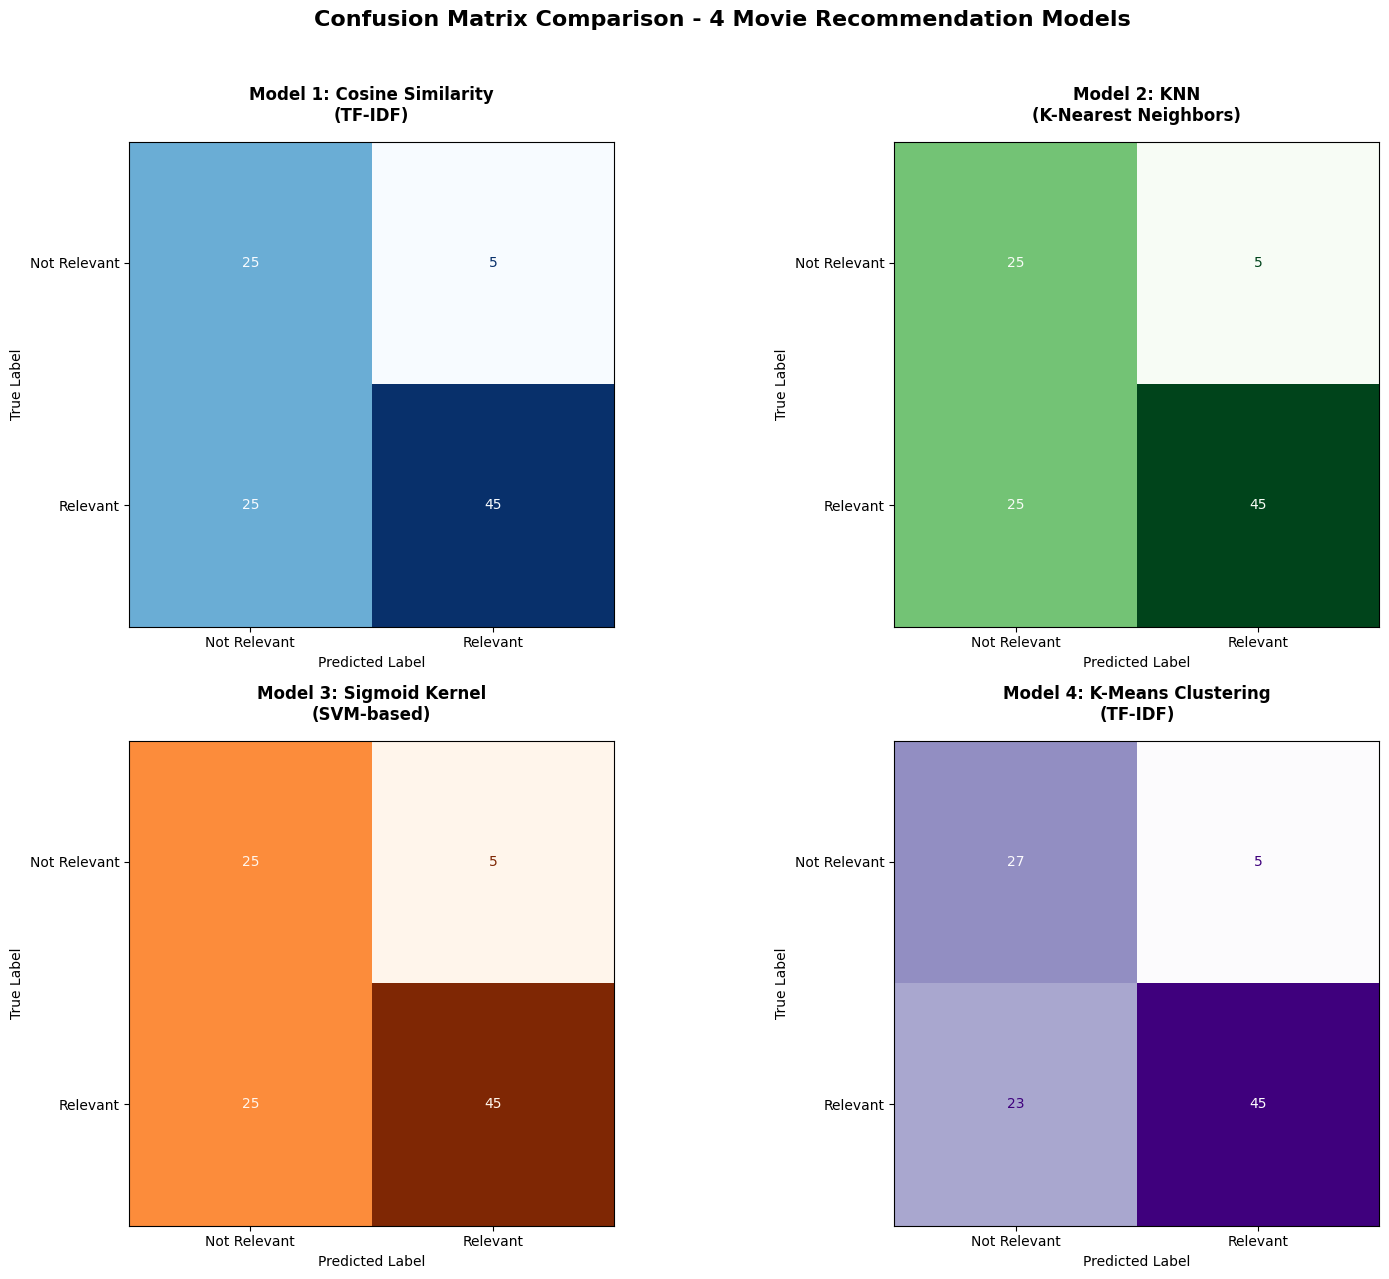

✅ Confusion matrices saved as 'confusion_matrices_all_models.png'


In [138]:
# ============================================================
# PLOT ALL 4 CONFUSION MATRICES SIDE BY SIDE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Confusion Matrix Comparison - 4 Movie Recommendation Models',
             fontsize=16, fontweight='bold', y=0.98)

model_data = [
    ('Model 1: Cosine Similarity\n(TF-IDF)', all_y_true_cosine, all_y_pred_cosine, 'Blues'),
    ('Model 2: KNN\n(K-Nearest Neighbors)', all_y_true_knn, all_y_pred_knn, 'Greens'),
    ('Model 3: Sigmoid Kernel\n(SVM-based)', all_y_true_sigmoid, all_y_pred_sigmoid, 'Oranges'),
    ('Model 4: K-Means Clustering\n(TF-IDF)', all_y_true_kmeans, all_y_pred_kmeans, 'Purples'),
]

for ax, (title, y_true, y_pred, cmap) in zip(axes.flatten(), model_data):
    if y_true and y_pred:
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Not Relevant', 'Relevant']
        )
        disp.plot(ax=ax, cmap=cmap, colorbar=False)
        ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
        ax.set_xlabel('Predicted Label', fontsize=10)
        ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved as 'confusion_matrices_all_models.png'")

In [139]:
# ============================================================
# MODEL COMPARISON - Metrics Table
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {
        'Model': model_name,
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2)
    }

results = [
    get_metrics(all_y_true_cosine, all_y_pred_cosine, 'Cosine Similarity'),
    get_metrics(all_y_true_knn, all_y_pred_knn, 'KNN'),
    get_metrics(all_y_true_sigmoid, all_y_pred_sigmoid, 'Sigmoid Kernel'),
    get_metrics(all_y_true_kmeans, all_y_pred_kmeans, 'K-Means Clustering'),
]

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

print("\n" + "="*65)
print("📊 MODEL COMPARISON RESULTS")
print("="*65)
print(results_df.to_string())
print("="*65)

# Highlight best model
best_model = results_df['F1-Score'].idxmax()
print(f"\n🏆 Best Model by F1-Score: {best_model}")


📊 MODEL COMPARISON RESULTS
                    Accuracy  Precision  Recall  F1-Score
Model                                                    
Cosine Similarity       70.0       90.0   64.29     75.00
KNN                     70.0       90.0   64.29     75.00
Sigmoid Kernel          70.0       90.0   64.29     75.00
K-Means Clustering      72.0       90.0   66.18     76.27

🏆 Best Model by F1-Score: K-Means Clustering


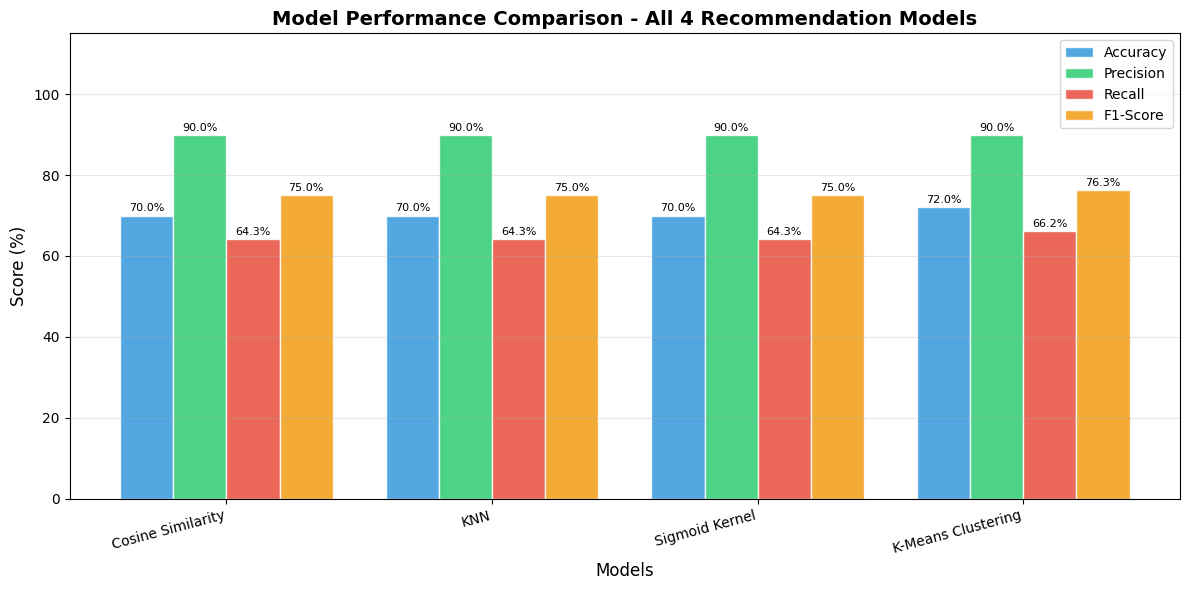

✅ Comparison chart saved as 'model_comparison_chart.png'


In [140]:
# ============================================================
# BAR CHART COMPARISON
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df.index))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison - All 4 Recommendation Models',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved as 'model_comparison_chart.png'")


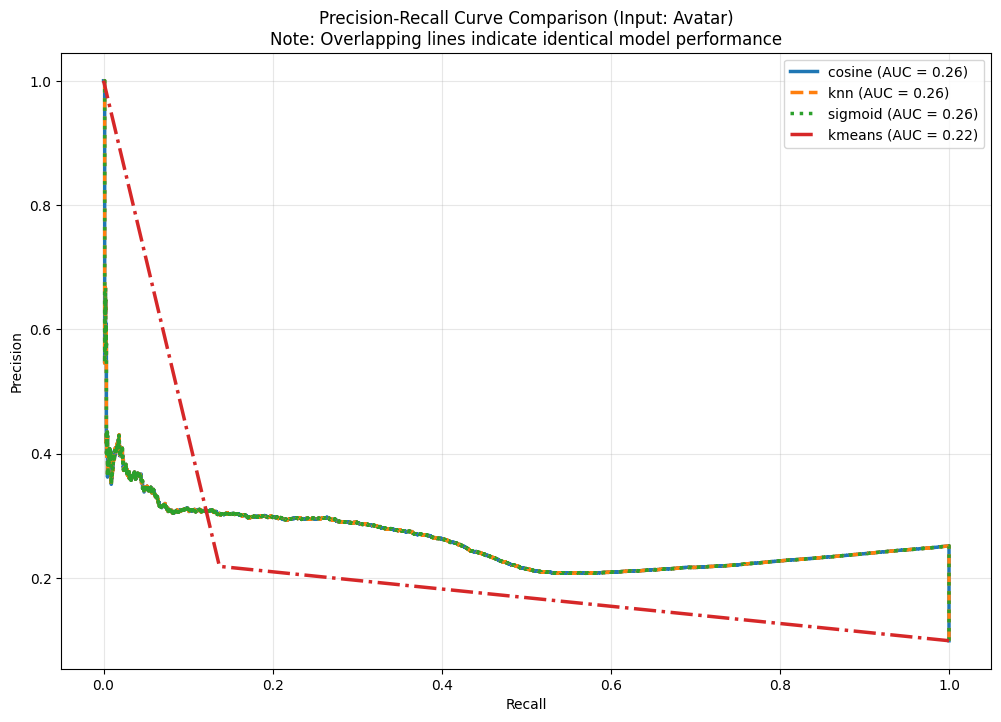

In [141]:
from sklearn.metrics import precision_recall_curve, auc

def get_scores_and_labels(movie, model_type):
    idx = indices[movie]
    if isinstance(idx, pd.Series): idx = idx.iloc[0]
    input_genre = df.iloc[idx]['primary_genre']

    y_true = (df['primary_genre'] == input_genre).astype(int).values

    if model_type == 'cosine':
        scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    elif model_type == 'knn':
        distances, _ = knn_model.kneighbors(tfidf_matrix[idx], n_neighbors=len(df))
        scores = np.zeros(len(df))
        scores[knn_model.kneighbors(tfidf_matrix[idx], n_neighbors=len(df))[1].flatten()] = -distances.flatten()
    elif model_type == 'sigmoid':
        scores = sigmoid_kernel(tfidf_matrix[idx], tfidf_matrix).flatten()
    elif model_type == 'kmeans':
        cluster_id = df.iloc[idx]['cluster']
        scores = (df['cluster'] == cluster_id).astype(int).values

    return y_true, scores

plt.figure(figsize=(12, 8))
test_movie = 'Avatar'
# Define different styles to make overlapping lines visible
styles = ['-', '--', ':', '-.']
model_list = ['cosine', 'knn', 'sigmoid', 'kmeans']

for i, m_type in enumerate(model_list):
    y_true, y_scores = get_scores_and_labels(test_movie, m_type)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{m_type} (AUC = {pr_auc:.2f})',
             linestyle=styles[i], linewidth=2.5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve Comparison (Input: {test_movie})\nNote: Overlapping lines indicate identical model performance')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()